## Phase 6 - Autoencoder Anomaly Detection (VitalWatch V2)

**Goal:** Replace Isolation Forest with a Deep Learning approach -
train an Autoencoder exclusively on normal beats so that abnormal
beats produce high reconstruction error and get flagged.

**Key difference from V1:**
Isolation Forest asks - "how hard is this point to isolate?"
Autoencoder asks - "how hard is this point to reconstruct?"
Same unsupervised philosophy. Deeper mechanism.

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


TensorFlow: 2.12.0
Keras: 2.12.0


In [2]:
# Load record
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

ecg_signal = record.p_signal[:, 0]
fs = record.fs
ann_samples = annotation.sample
ann_symbols = annotation.symbol

# Rebuild all 6 features
rr_intervals = np.diff(ann_samples)
rr_ms = (rr_intervals / fs) * 1000
heart_rate = 60000 / rr_ms
rr_diff = np.append(0, np.diff(rr_ms))
rolling_mean_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).mean().values
rolling_std_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).std().fillna(0).values
relative_rr = rr_ms / rolling_mean_rr

feature_df = pd.DataFrame({
    'sample': ann_samples[1:],
    'symbol': ann_symbols[1:],
    'rr_interval': rr_ms,
    'heart_rate': heart_rate,
    'rr_diff': rr_diff,
    'rolling_mean_rr': rolling_mean_rr,
    'rolling_std_rr': rolling_std_rr,
    'relative_rr': relative_rr,
})

print(f"Feature DataFrame - shape: {feature_df.shape}")

Feature DataFrame - shape: (2273, 8)


In [3]:
# Separate normal and abnormal beats
normal_df = feature_df[feature_df['symbol'] == 'N']
abnormal_df = feature_df[feature_df['symbol'] != 'N']

print(f"Normal beats: {len(normal_df)}")
print(f"Abnormal beats: {len(abnormal_df)}")

features = ['rr_interval', 'heart_rate', 'rr_diff', 'rolling_mean_rr', 'rolling_std_rr', 'relative_rr']

# Scale - fit ONLY on normal beats
# This is the critical difference from Isolation Forest
# The scaler learns what normal looks like
scaler = StandardScaler()
X_normal = scaler.fit_transform(normal_df[features].values)
X_abnormal = scaler.transform(abnormal_df[features].values)
X_all = scaler.transform(feature_df[features].values)

print(f"Scaler fitted on normal beats only - {len(X_normal)} samples")

Normal beats: 2239
Abnormal beats: 34
Scaler fitted on normal beats only - 2239 samples


### Why fit the scaler on normal beats only?

In Phase 3-5 we scaled all data together.
Here we fit exclusively on normal beats.

The scaler's mean and std now represent what normal looks like.
When abnormal beats pass through, they are measured against
the normal baseline - not their own distribution.

This is a stronger form of the same data integrity principle
we applied in Phase 5 with the train/stream split.

In [4]:
# Define input shape
input_dim = X_normal.shape[1]  # 6 features

# Build architecture
inputs = Input(shape=(input_dim,))

# Encoder
encoded = Dense(32, activation='relu')(inputs)
encoded = Dense(16, activation='relu')(encoded)

# Decoder
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Wrap into model
autoencoder = Model(inputs=inputs, outputs=decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

# Print architecture summary
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 6)]               0         
                                                                 
 dense (Dense)               (None, 32)                224       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 32)                544       
                                                                 
 dense_3 (Dense)             (None, 6)                 198       
                                                                 
Total params: 1,494
Trainable params: 1,494
Non-trainable params: 0
_________________________________________________________________


### Architecture - Reading the Summary

Input: 6 features
-> Dense(32, relu)   - Encoder layer 1, expanding representation
-> Dense(16, relu)   - Bottleneck - forced compression
-> Dense(32, relu)   - Decoder layer 1, expanding back
-> Dense(6, linear)  - Output - reconstructed 6 features

The bottleneck at 16 neurons is the critical layer.
It forces the model to learn the most compact representation
of normal rhythm possible - discarding noise, keeping signal.
Anything that doesn't compress and reconstruct well is anomalous.

Epoch 1/100
63/63 [==============================] - 1s 4ms/step - loss: 0.9368 - val_loss: 0.6318
Epoch 2/100
63/63 [==============================] - 0s 2ms/step - loss: 0.5625 - val_loss: 0.3152
Epoch 3/100
63/63 [==============================] - 0s 2ms/step - loss: 0.3213 - val_loss: 0.1010
Epoch 4/100
63/63 [==============================] - 0s 2ms/step - loss: 0.1914 - val_loss: 0.0504
Epoch 5/100
63/63 [==============================] - 0s 2ms/step - loss: 0.1100 - val_loss: 0.0387
Epoch 6/100
63/63 [==============================] - 0s 2ms/step - loss: 0.0709 - val_loss: 0.0375
Epoch 7/100
63/63 [==============================] - 0s 2ms/step - loss: 0.0460 - val_loss: 0.0338
Epoch 8/100
63/63 [==============================] - 0s 2ms/step - loss: 0.0277 - val_loss: 0.0160
Epoch 9/100
63/63 [==============================] - 0s 2ms/step - loss: 0.0211 - val_loss: 0.0222
Epoch 10/100
63/63 [==============================] - 0s 2ms/step - loss: 0.0133 - val_loss: 0.0167
Epoch 11/

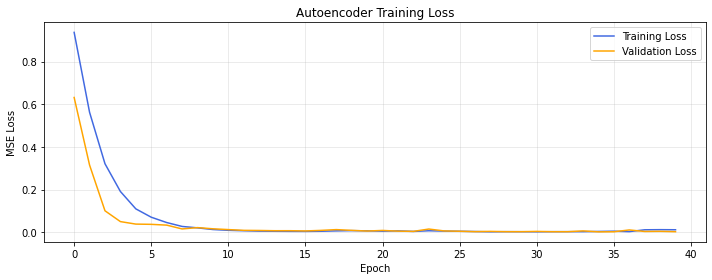

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_normal, X_normal,        # Input AND output are the same
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the Training Curve

Both training and validation loss should decrease and converge.
If validation loss starts rising while training loss falls -
the model is overfitting to the normal beats it has seen.

EarlyStopping with patience=5 prevents this automatically -
it restores the best weights before overfitting begins.

In [6]:
# Reconstruct all beats
X_reconstructed = autoencoder.predict(X_all)

# Calculate reconstruction error per beat (MSE per sample)
reconstruction_errors = np.mean(
    np.power(X_all - X_reconstructed, 2), axis=1)

feature_df['reconstruction_error'] = reconstruction_errors

# Set threshold - 95th percentile of normal beat errors
normal_errors = reconstruction_errors[feature_df['symbol'] == 'N']
threshold = np.percentile(normal_errors, 95)

print(f"Reconstruction error threshold (95th percentile): {threshold:.6f}")
print(f"\nNormal beats - mean error:    "
      f"{normal_errors.mean():.6f}")
print(f"Abnormal beats - mean error:  "
      f"{reconstruction_errors[feature_df['symbol'] != 'N'].mean():.6f}")

72/72 [==============================] - 0s 2ms/step
Reconstruction error threshold (95th percentile): 0.005337

Normal beats - mean error:    0.004313
Abnormal beats - mean error:  0.302682


### Reading the Reconstruction Errors

If normal mean error << abnormal mean error -
the Autoencoder has learned to distinguish normal from abnormal
purely through reconstruction quality. No labels. No supervision.

The threshold at the 95th percentile means:
95% of normal beats are considered "reconstructable."
Anything above this line the model flags as - 
"I've never seen this pattern. Something is wrong."

## Phase 6 Complete - Autoencoder Deployed

VitalWatch V2 introduces Deep Learning anomaly detection
on the same data and features as V1 - enabling direct comparison.

The Autoencoder was trained on 2239 normal beats only.
It learned what normal cardiac rhythm looks like.
It has never seen an abnormal beat.

The comparison between Isolation Forest and Autoencoder
on identical data and features is what makes V2 meaningful -
not just a new model, but a deeper understanding of the problem.

Next - Phase 7: Multi-patient generalisation.
Does the model hold when it sees a heart it has never trained on?